In [ ]:
# pip install pandas


In [5]:
import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import platform

print("Torch Loaded") # Torch takes awhile to import



Torch Loaded


In [4]:

import platform
def get_platform_device():
    '''

    Detects the OS and the best GPU to use on the device

    '''
    
    os_name = platform.system()
    processor = platform.processor()
    

    if torch.cuda.is_available():
        device = "cuda"
        platform_info = f"Nvidia GPU via CUDA ({os_name})"
    elif torch.backends.mps.is_available():
        device = "mps"
        platform_info = f"Apple Silicon via MPS ({os_name})"
    else:
        device = "cpu"
        platform_info = f"CPU fallback ({os_name} {processor})"
    
    print(f"Platform detected: {platform_info}")
    return device

device = get_platform_device()
print(f"Using device: {device}")

Platform detected: Apple Silicon via MPS (Darwin)
Using device: mps


In [8]:
train_df = pd.read_csv("data/asl_data/sign_mnist_train.csv")
valid_df = pd.read_csv("data/asl_data/sign_mnist_valid.csv")
print("Executed") # Takes awhile to execute, this is to make sure it executes fully

Executed


In [9]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,12,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [10]:
y_train = train_df.pop('label')
y_valid = valid_df.pop('label')
y_train

0         3
1         6
2         2
3         2
4        12
         ..
27450    12
27451    22
27452    17
27453    16
27454    22
Name: label, Length: 27455, dtype: int64

In [12]:
x_train = train_df.values
x_valid = valid_df.values
x_train # Outputs dataframe

array([[107, 118, 127, ..., 204, 203, 202],
       [155, 157, 156, ..., 103, 135, 149],
       [187, 188, 188, ..., 195, 194, 195],
       ...,
       [174, 174, 174, ..., 202, 200, 200],
       [177, 181, 184, ...,  64,  87,  93],
       [179, 180, 180, ..., 205, 209, 215]], shape=(27455, 784))

In [13]:
x_train.shape

(27455, 784)

In [14]:
y_train.shape

(27455,)

In [16]:
x_valid.shape
y_valid.shape

(7172,)

In [17]:
import matplotlib.pyplot as plt

In [18]:
def visualize_data() -> None:


    plt.figure(figsize=(40,40))
    
    num_images = 20
    for i in range(num_images):
        row = x_train[i]
        label = y_train[i]
    
        image = row.reshape(28,28)
        plt.subplot(1, num_images, i+1)
        plt.title(label, fontdict={'fontsize': 30})
        plt.axis('off')
        plt.imshow(image, cmap='gray')


    

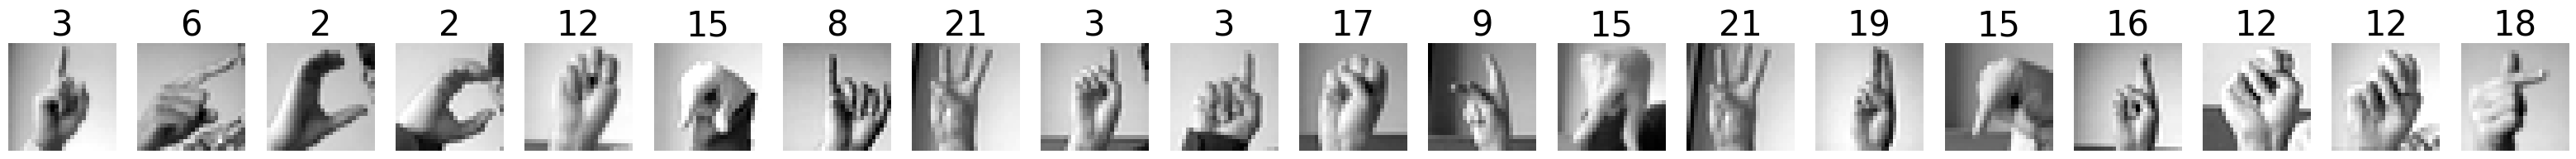

In [19]:
visualize_data()

In [20]:
x_train.min()

np.int64(0)

In [21]:
x_train.max()


np.int64(255)

In [22]:
x_train = train_df.values / 255
x_valid = valid_df.values / 255

In [23]:
class MyDataset(Dataset):
    '''
    Custom Dataset

    '''
    def __init__(self, x_df, y_df):
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

In [28]:
BATCH_SIZE = 32 #Constant

train_data = MyDataset(x_train, y_train)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
train_N = len(train_loader.dataset)


valid_data = MyDataset(x_valid, y_valid)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE)
valid_N = len(valid_loader.dataset)

In [29]:
train_loader

In [31]:
batch = next(iter(train_loader))
batch

[tensor([[0.7804, 0.7843, 0.7922,  ..., 0.8588, 0.8549, 0.8431],
         [0.4275, 0.3961, 0.4039,  ..., 0.3569, 0.3137, 0.2745],
         [0.1961, 0.2078, 0.2235,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.5137, 0.5373, 0.5569,  ..., 0.6392, 0.6431, 0.6706],
         [0.3098, 0.3255, 0.3373,  ..., 0.6471, 0.6471, 0.6471],
         [0.6353, 0.6431, 0.6549,  ..., 0.8000, 0.7569, 0.6627]],
        device='mps:0'),
 tensor([18, 14, 15, 23, 22, 12,  5, 10, 13, 17,  7, 13, 22,  2,  4, 16,  5, 19,
         13,  3, 21, 19, 14, 13, 18, 23,  2, 20,  6, 20, 16,  8],
        device='mps:0')]

In [32]:
batch[0].shape

torch.Size([32, 784])

In [33]:
batch[1].shape


torch.Size([32])

In [36]:
# Building the model

In [47]:
# This is done on a single row to prevent name shadowing
input_size = 28 * 28
n_classes = 24

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(input_size, 512),
    nn.ReLU(),
    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, n_classes)
)


model = torch.compile(model.to(device))
print("Compiled model")
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters())
print("Completed!")

Compiled model
Completed!


In [41]:
# Training

AttributeError: 'function' object has no attribute 'to'

In [57]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N


def train():
    loss = 0
    accuracy = 0

    model.train()
    for x, y in train_loader:
        output = model(x)
        optimizer.zero_grad()
        batch_loss = loss_function(output, y)
        batch_loss.backward()
        optimizer.step()

        loss += batch_loss.item()
        accuracy += get_batch_accuracy(output, y, train_N)
    print('Train - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

In [59]:
def validate():
    loss = 0
    accuracy = 0

    model.eval()
    with torch.no_grad():
        for x, y in valid_loader:
            output = model(x)

            loss += loss_function(output, y).item()
            accuracy += get_batch_accuracy(output, y, valid_N)
    print('Valid - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

In [61]:
epochs = 20
for epoch in range(epochs):
    print(f"Epoch: {epoch+1}")
    train()
    validate()
print("Training Complete")

Epoch: 1
Train - Loss: 0.5369 Accuracy: 1.0000
Valid - Loss: 264.5834 Accuracy: 0.8371
Epoch: 2
Train - Loss: 0.3375 Accuracy: 1.0000
Valid - Loss: 276.0344 Accuracy: 0.8321
Epoch: 3
Train - Loss: 106.8519 Accuracy: 0.9752
Valid - Loss: 233.5355 Accuracy: 0.7980
Epoch: 4
Train - Loss: 4.7436 Accuracy: 0.9999
Valid - Loss: 259.8293 Accuracy: 0.8047
Epoch: 5
Train - Loss: 46.3434 Accuracy: 0.9843
Valid - Loss: 229.0009 Accuracy: 0.8265
Epoch: 6
Train - Loss: 1.1906 Accuracy: 1.0000
Valid - Loss: 241.6890 Accuracy: 0.8309
Epoch: 7
Train - Loss: 68.2521 Accuracy: 0.9796
Valid - Loss: 240.0320 Accuracy: 0.7854
Epoch: 8
Train - Loss: 2.1379 Accuracy: 0.9999
Valid - Loss: 239.3771 Accuracy: 0.8214
Epoch: 9
Train - Loss: 0.8898 Accuracy: 1.0000
Valid - Loss: 252.6472 Accuracy: 0.8259
Epoch: 10
Train - Loss: 9.0626 Accuracy: 0.9975
Valid - Loss: 516.1168 Accuracy: 0.6247
Epoch: 11
Train - Loss: 54.4945 Accuracy: 0.9822
Valid - Loss: 228.8434 Accuracy: 0.8284
Epoch: 12
Train - Loss: 0.9954 Accur

In [62]:
# Shutdown

import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}